# Complemento prático — Dia 2: Estatística Espacial com SICOR + estações INMET

Este notebook foi montado como apoio à aula sobre:

1. Lei de Tobler  
2. I de Moran global  
3. matriz de vizinhança  
4. significância por permutação  
5. diagrama de Moran  
6. LISA  
7. coerência espacial entre sinistros e clima  
8. recorrência temporal  
9. estratificação por agente  
10. MAUP

## Premissas deste notebook

- arquivo `sicor-interest-data.csv` no mesmo diretório do notebook;
- arquivos horários do INMET em `INMET/*/*.CSV`;
- foco didático: aqui a unidade espacial principal será uma **grade regular**, para evitar depender de shapefile municipal;
- o exemplo de clima usa a **estação mais próxima** de cada registro do SICOR.

> **Importante:** o objetivo aqui é mostrar o fluxo de trabalho. Para uso operacional, vale trocar a grade por município/gleba, revisar a janela climática e validar a vizinhança com mais de um critério.

In [5]:
# Se precisar instalar as bibliotecas, rode esta célula uma vez.
!pip install cartopy libpysal esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 122.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/MaterialGeotec/basededados/

/content/drive/MyDrive/MaterialGeotec/basededados


In [6]:
from pathlib import Path
import glob
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

from scipy.spatial import cKDTree
from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda import Moran, Moran_Local

pd.set_option("display.max_columns", 50)

In [7]:
# Construção de funções que serão usadas no decorrer deste colab

COLUNAS_INMET = [
    "DATA", "HORA", "PREC", "PATM", "PATM_MAX", "PATM_MIN", "RAD",
    "TEMP", "TD", "TMAX", "TMIN", "TD_MAX", "TD_MIN",
    "UR_MAX", "UR_MIN", "UR", "VENTO_DIR", "VENTO_RAJ", "VENTO_VEL",
]

def normalizar_texto(txt):
    txt = str(txt).strip()
    txt = unicodedata.normalize("NFKD", txt).encode("ascii", "ignore").decode("ascii")
    return txt.upper()

def to_float_br(valor):
    if pd.isna(valor):
        return np.nan
    valor = str(valor).strip()
    if not valor:
        return np.nan
    valor = valor.replace(",", ".")
    valor = re.sub(r"[^0-9+\-\.]", "", valor)
    try:
        return float(valor)
    except ValueError:
        return np.nan

def ler_meta_inmet(caminho, n_header=8):
    meta = {}
    with open(caminho, "r", encoding="latin1") as f:
        linhas = [next(f).strip() for _ in range(n_header)]

    for linha in linhas:
        if ":" not in linha:
            continue
        chave, valor = linha.split(":", 1)
        meta[normalizar_texto(chave)] = valor.strip()

    cod = (
        meta.get("CODIGO (WMO)")
        or meta.get("CODIGO")
        or meta.get("CODIGO ESTACAO")
        or Path(caminho).stem
    )

    nome = (
        meta.get("ESTACAO")
        or meta.get("NOME")
        or Path(caminho).stem
    )

    latitude = np.nan
    longitude = np.nan
    altitude = np.nan

    for chave, valor in meta.items():
        if "LATITUDE" in chave:
            latitude = to_float_br(valor)
        elif "LONGITUDE" in chave:
            longitude = to_float_br(valor)
        elif "ALTITUDE" in chave:
            altitude = to_float_br(valor)

    return {
        "arquivo": caminho,
        "COD": str(cod).strip(),
        "ESTACAO": str(nome).strip(),
        "latitude": latitude,
        "longitude": longitude,
        "altitude_m": altitude,
    }

def ler_arquivo_inmet(caminho):
    meta = ler_meta_inmet(caminho)
    print(caminho)

    df = pd.read_csv(
        caminho,
        encoding="latin1",
        sep=";",
        decimal=",",
        skiprows=8,
    )

    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df.columns = COLUNAS_INMET[:len(df.columns)]
    df.rename(
        columns={df.columns[0]: "DATA", df.columns[1]: "HORA"},
        inplace=True,
    )

    df["HORA"] = (
        df["HORA"].astype(str)
        .str.strip()
        .str.replace(" UTC", "", regex=False)
        .str.replace(r"^(\d{2})(\d{2})$", r"\1:\2", regex=True)
    )

    df["DATA"] = (
        df["DATA"].astype(str)
        .str.strip()
        .str.replace("/", "-", regex=False)
    )

    for col in [c for c in COLUNAS_INMET if c in df.columns[2:]]:
        df[col] = (
            df[col].astype(str)
            .str.replace(",", ".", regex=False)
            .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["COD"] = meta["COD"]
    df["ESTACAO"] = meta["ESTACAO"]
    df["latitude_estacao"] = meta["latitude"]
    df["longitude_estacao"] = meta["longitude"]
    df["altitude_m"] = meta["altitude_m"]
    df.index = pd.to_datetime(df["DATA"] + " " + df["HORA"], errors="coerce")
    df = df[~df.index.isna()].copy()

    return df, meta

def carregar_inmet(padrao="INMET/*/*.CSV"):
    arquivos = sorted(glob.glob(padrao))
    if not arquivos:
        raise FileNotFoundError("Nenhum arquivo INMET encontrado em INMET/*/*.CSV")

    frames = []
    metas = []

    for caminho in arquivos:
        try:
            df_tmp, meta_tmp = ler_arquivo_inmet(caminho)
            frames.append(df_tmp)
            metas.append(meta_tmp)
        except Exception as e:
            print(f"Falha ao ler {caminho}: {e}")

    if not frames:
        raise RuntimeError("Nenhum arquivo INMET foi carregado com sucesso.")

    df_all = pd.concat(frames, ignore_index=False)
    df_meta = pd.DataFrame(metas).drop_duplicates(subset=["COD"])
    return df_all, df_meta

def preparar_sicor(caminho="sicor-interest-data.csv"):
    df = pd.read_csv(caminho)

    if "longitude_centroide" in df.columns and "latitude_centroide" in df.columns:
        df = df.rename(
            columns={
                "longitude_centroide": "longitude",
                "latitude_centroide": "latitude",
            }
        )

    if "longitude" in df.columns:
        df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
        df["longitude"] = df["longitude"].abs() * -1

    if "latitude" in df.columns:
        df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")

    datas = [
        "dt_inicio_evento", "dt_fim_evento", "dt_comunicacao",
        "dt_inicio_plantio", "dt_fim_plantio",
        "dt_inicio_colheita", "dt_fim_colheita",
        "data_inicial_decendio", "data_final_decendio",
    ]
    for col in datas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    if "ano_emissao" in df.columns:
        df["ano_emissao"] = pd.to_numeric(df["ano_emissao"], errors="coerce")

    if "risco_percentual" in df.columns:
        df["risco_percentual"] = pd.to_numeric(df["risco_percentual"], errors="coerce")

    if "area_gleba_ha" in df.columns:
        df["area_gleba_ha"] = pd.to_numeric(df["area_gleba_ha"], errors="coerce")

    df = df.dropna(subset=["longitude", "latitude"]).copy()
    return df

def agregar_em_grade(df, step=0.5, lon="longitude", lat="latitude"):
    out = df.copy()
    out["x_bin"] = np.floor(out[lon] / step) * step
    out["y_bin"] = np.floor(out[lat] / step) * step
    out["grid_lon"] = out["x_bin"] + step / 2
    out["grid_lat"] = out["y_bin"] + step / 2
    out["grid_id"] = (
        out["grid_lon"].round(4).astype(str)
        + "_"
        + out["grid_lat"].round(4).astype(str)
    )
    return out

def construir_knn(df_xy, k=5):
    if len(df_xy) <= 2:
        raise ValueError("É preciso ter ao menos 3 unidades espaciais.")
    k = min(k, len(df_xy) - 1)
    w = KNN.from_array(df_xy[["grid_lon", "grid_lat"]].to_numpy(), k=k)
    w.transform = "R"
    return w

def classificar_lisa(q, p, alpha=0.05):
    if p >= alpha:
        return "NS"
    return {1: "HH", 2: "LH", 3: "LL", 4: "HL"}.get(q, "NS")

def resumo_moran(serie, pesos, nome, permutacoes=999):
    moran = Moran(
        serie.to_numpy(),
        pesos,
        permutations=permutacoes,
    )
    return {
        "variavel": nome,
        "I": moran.I,
        "p_sim": moran.p_sim,
        "z_sim": moran.z_sim,
        "EI": moran.EI,
        "permutacoes": permutacoes,
    }, moran

def escolher_janela_evento(row):
    ini = row.get("dt_inicio_evento")
    fim = row.get("dt_fim_evento")
    comunic = row.get("dt_comunicacao")

    if pd.isna(ini) and pd.notna(comunic):
        ini = comunic - pd.Timedelta(days=7)
    if pd.isna(fim) and pd.notna(comunic):
        fim = comunic
    if pd.isna(ini) and pd.notna(fim):
        ini = fim - pd.Timedelta(days=7)
    if pd.notna(ini) and pd.isna(fim):
        fim = ini + pd.Timedelta(days=7)

    return pd.Series({"janela_ini": ini, "janela_fim": fim})

def clima_no_evento(row, diarios_por_estacao):
    cod = row["COD_ESTACAO"]
    ini = row["janela_ini"]
    fim = row["janela_fim"]

    if pd.isna(cod) or pd.isna(ini) or pd.isna(fim):
        return pd.Series(
            {
                "prec_evento_mm": np.nan,
                "temp_media_evento_c": np.nan,
                "tmin_evento_c": np.nan,
                "n_dias_clima": 0,
            }
        )

    serie = diarios_por_estacao.get(cod)
    if serie is None:
        return pd.Series(
            {
                "prec_evento_mm": np.nan,
                "temp_media_evento_c": np.nan,
                "tmin_evento_c": np.nan,
                "n_dias_clima": 0,
            }
        )

    sub = serie.loc[(serie.index >= ini) & (serie.index <= fim)]
    if sub.empty:
        return pd.Series(
            {
                "prec_evento_mm": np.nan,
                "temp_media_evento_c": np.nan,
                "tmin_evento_c": np.nan,
                "n_dias_clima": 0,
            }
        )

    return pd.Series(
        {
            "prec_evento_mm": sub["PREC"].sum(min_count=1),
            "temp_media_evento_c": sub["TEMP"].mean(),
            "tmin_evento_c": sub["TMIN"].min(),
            "n_dias_clima": int(sub.shape[0]),
        }
    )

def mapa_cluster(ax, df, coluna, titulo):
    cores = {
        "HH": "tab:red",
        "LL": "tab:blue",
        "HL": "tab:orange",
        "LH": "lightskyblue",
        "NS": "lightgray",
    }
    for classe, sub in df.groupby(coluna):
        ax.scatter(
            sub["grid_lon"],
            sub["grid_lat"],
            s=70,
            c=cores.get(classe, "lightgray"),
            label=classe,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.4,
        )
    ax.set_title(titulo)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(title="Cluster", loc="best")

## 1. Carregamento dos dados

In [10]:
df_sicor = preparar_sicor("sicor-interest-data.csv")
df_sicor.head()

,ref_bacen,status_cop,nome_evento,produto,descricao_ciclo,dt_inicio_evento,dt_fim_evento,dt_comunicacao,cd_cpf_perito,dt_inicio_plantio,dt_fim_plantio,dt_inicio_colheita,dt_fim_colheita,area_gleba_ha,data_inicial_decendio,data_final_decendio,risco_percentual,nu_indice,longitude,latitude,ano_emissao,cd_ibge_municipio,cd_estado
0,516578816,deferida,Chuva excessiva,soja,grupo ii,2024-01-15,2024-03-26,2024-03-26,3.303149e+09,2023-11-01,2023-11-20,2024-04-10,2024-04-30,11.794878,NaT,NaT,NaN,0.0,-52.452023,-27.643629,2023,4314787,RS
11,509939195,deferida,Seca,trigo,grupo ii,2020-09-27,2020-10-15,2020-10-15,NaN,2020-05-11,2020-06-26,2020-10-25,2020-10-30,42.185319,NaT,NaT,NaN,0.0,-55.256329,-27.941107,2020,4315107,RS
12,512442149,deferida,Seca,soja,grupo iii,2021-11-20,2022-02-01,2022-03-08,NaN,2021-10-27,2021-10-28,2022-03-20,2022-03-30,18.317065,NaT,NaT,NaN,0.0,-52.957163,-29.195475,2021,4301206,RS
14,514182145,deferida,Seca,milho,grupo iii,2022-10-20,2023-02-09,2023-02-09,NaN,2022-09-15,2022-10-15,2023-03-15,2023-04-05,38.934856,NaT,NaT,NaN,0.0,-52.193300,-28.242409,2022,4312138,RS
15,513532353,deferida,Chuva excessiva,feijão,grupo iii,2022-05-05,2022-06-06,2022-06-06,NaN,2022-02-23,2022-02-25,2022-06-08,2022-06-10,4.073600,NaT,NaT,NaN,0.0,-52.511612,-27.740961,2022,4310900,RS


In [12]:
# corrigindo as coordenadas que veio estranhas do banco de dados...
# EXPLICADO NA AULA ANTERIOR
df_sicor['longitude'] = df_sicor['longitude'].abs()*-1
df_sicor = df_sicor.loc[df_sicor['latitude'][(df_sicor['latitude'] >= -34) & (df_sicor['latitude'] <= -20)].index]
df_sicor = df_sicor.loc[df_sicor['longitude'][(df_sicor['longitude'] >= -60) & (df_sicor['longitude'] <= -41)].index]

In [13]:
df_est, meta_est = carregar_inmet("INMET/*/*_S_*.CSV")

print(f"Registros SICOR: {len(df_sicor):,}")
print(f"Registros horários INMET: {len(df_est):,}")
print(f"Estações carregadas: {meta_est['COD'].nunique():,}")

display(df_sicor[["nome_evento", "produto", "ano_emissao"]].head())
display(meta_est.head())

INMET/2014/INMET_S_PR_A807_CURITIBA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A818_IVAI_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A819_CASTRO_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A820_MAL. CANDIDO RONDON_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A821_JOAQUIM TAVORA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A822_NOVA TEBAS_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A823_INACIO MARTINS_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A824_ICARAIMA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A835_MARINGA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A842_NOVA FATIMA_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A843_DOIS VIZINHOS_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A846_FOZ DO IGUACU_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A847_ILHA DO MEL_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A849_DIAMANTE DO NORTE_01-01-2014_A_31-12-2014.CSV
INMET/2014/INMET_S_PR_A850_PARANAPOEMA_01-01-2014_A_31-12-201

/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": np.nan, "nan": np.nan, "None": np.nan})
/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": np.nan, "nan": np.nan, "None": np.nan})
/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, s

INMET/2021/INMET_S_PR_A823_INACIO_MARTINS_01-01-2021_A_31-12-2021.CSV
INMET/2021/INMET_S_PR_A824_ICARAIMA_01-01-2021_A_31-12-2021.CSV


/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": np.nan, "nan": np.nan, "None": np.nan})
/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": np.nan, "nan": np.nan, "None": np.nan})
/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, s

INMET/2021/INMET_S_PR_A825_GOIOERE_01-01-2021_A_31-12-2021.CSV
INMET/2021/INMET_S_PR_A835_MARINGA_01-01-2021_A_31-12-2021.CSV
INMET/2021/INMET_S_PR_A842_NOVA_FATIMA_01-01-2021_A_31-12-2021.CSV


...

INMET/2025/INMET_S_SC_A895_CHAPECO_01-01-2025_A_31-12-2025.CSV


/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": np.nan, "nan": np.nan, "None": np.nan})
/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"": np.nan, "nan": np.nan, "None": np.nan})
/tmp/ipykernel_12607/804759803.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, s

INMET/2025/INMET_S_SC_A898_CAMPOS_NOVOS_01-01-2025_A_30-11-2025.CSV
INMET/2025/INMET_S_SC_A898_CAMPOS_NOVOS_01-01-2025_A_31-12-2025.CSV
Registros SICOR: 1,285,841
Registros horários INMET: 10,388,088
Estações carregadas: 121


,nome_evento,produto,ano_emissao
0,Chuva excessiva,soja,2023
11,Seca,trigo,2020
12,Seca,soja,2021
14,Seca,milho,2022
15,Chuva excessiva,feijão,2022


,arquivo,COD,ESTACAO,latitude,longitude,altitude_m
0,INMET/2014/INMET_S_PR_A807_CURITIBA_01-01-2014...,;A807,;CURITIBA,-25.433333,-49.266667,923.50
1,INMET/2014/INMET_S_PR_A818_IVAI_01-01-2014_A_3...,;A818,;IVAI,-25.013333,-50.871111,808.00
2,INMET/2014/INMET_S_PR_A819_CASTRO_01-01-2014_A...,;A819,;CASTRO,-24.789444,-49.999722,1007.76
3,INMET/2014/INMET_S_PR_A820_MAL. CANDIDO RONDON...,;A820,;MAL. CANDIDO RONDON,-24.535833,-54.019722,392.00
4,INMET/2014/INMET_S_PR_A821_JOAQUIM TAVORA_01-0...,;A821,;JOAQUIM TAVORA,-23.505278,-49.946389,522.00


In [14]:
df_est_daily = (
    df_est
    .groupby(["COD", pd.Grouper(freq="D")])
    .agg(
        PREC=("PREC", "sum"),
        TEMP=("TEMP", "mean"),
        TMIN=("TMIN", "min"),
        TMAX=("TMAX", "max"),
    )
    .reset_index()
    .rename(columns={"level_1": "DATA"})
)

df_est_daily["DATA"] = pd.to_datetime(df_est_daily["DATA"])
df_est_daily = df_est_daily.sort_values(["COD", "DATA"])

display(df_est_daily.head())

,COD,DATA,PREC,TEMP,TMIN,TMAX
0,;A801,2014-01-01,0.0,27.358333,23.5,34.1
1,;A801,2014-01-02,0.4,28.037500,24.7,34.4
2,;A801,2014-01-03,13.8,21.862500,19.4,27.9
3,;A801,2014-01-04,0.0,22.454167,17.4,28.7
4,;A801,2014-01-05,0.0,24.358333,17.6,32.5


## 2. Unidade espacial simples: grade regular

Para não depender de malha municipal, vamos transformar os registros do SICOR em uma grade regular.

Isso resolve duas coisas:

- cria uma **unidade espacial** para Moran e LISA;
- deixa o exemplo mais leve para aula.

No uso operacional, você pode trocar a grade por município, microrregião ou até gleba.

In [15]:
step = 0.5  # tamanho da célula em graus

sicor_grade = agregar_em_grade(df_sicor, step=step)

grid_cops = (
    sicor_grade
    .groupby(["grid_id", "grid_lon", "grid_lat"])
    .agg(
        n_cops=("ref_bacen", "size"),
        risco_medio=("risco_percentual", "mean"),
        area_media_ha=("area_gleba_ha", "mean"),
        n_anos=("ano_emissao", "nunique"),
        n_peritos=("cd_cpf_perito", "nunique"),
    )
    .reset_index()
    .sort_values("n_cops", ascending=False)
    .reset_index(drop=True)
)

print(f"Células ocupadas: {len(grid_cops):,}")
display(grid_cops.head())

Células ocupadas: 401


,grid_id,grid_lon,grid_lat,n_cops,risco_medio,area_media_ha,n_anos,n_peritos
0,-53.25_-25.75,-53.25,-25.75,76058,24.395904,7.861026,10,134
1,-52.75_-25.75,-52.75,-25.75,55071,24.894212,9.358453,10,123
2,-53.25_-27.75,-53.25,-27.75,52976,22.523062,8.354320,9,92
3,-53.75_-25.75,-53.75,-25.75,47625,27.434238,7.961390,10,63
4,-53.25_-27.25,-53.25,-27.25,43385,25.414004,4.706908,9,63


## 3. Lei de Tobler — exemplo curto

A ideia aqui é simples:

- calcular o valor da célula (`n_cops`);
- calcular a média dos vizinhos mais próximos;
- ver se células com muitos registros tendem a estar perto de células também altas.

Se essa correlação for positiva, já temos um primeiro sinal coerente com a Lei de Tobler.

Correlação valor × média dos vizinhos: 0.783


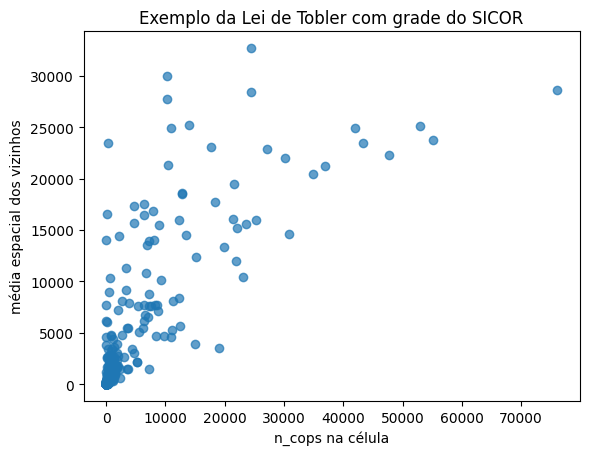

In [16]:
w5 = construir_knn(grid_cops, k=5)

grid_cops["lag_n_cops"] = lag_spatial(w5, grid_cops["n_cops"].to_numpy())

corr_tobler = np.corrcoef(
    grid_cops["n_cops"],
    grid_cops["lag_n_cops"],
)[0, 1]

print(f"Correlação valor × média dos vizinhos: {corr_tobler:.3f}")

fig, ax = plt.subplots()
ax.scatter(
    grid_cops["n_cops"],
    grid_cops["lag_n_cops"],
    alpha=0.7,
)
ax.set_xlabel("n_cops na célula")
ax.set_ylabel("média espacial dos vizinhos")
ax.set_title("Exemplo da Lei de Tobler com grade do SICOR")
plt.show()

## 4. I de Moran global e sensibilidade da vizinhança

In [17]:
resumos = []

for k in [5, 8]:
    w = construir_knn(grid_cops, k=k)
    resumo, moran_obj = resumo_moran(
        grid_cops["n_cops"],
        w,
        nome=f"n_cops | k={k}",
        permutacoes=999,
    )
    resumo["k"] = k
    resumos.append(resumo)

df_moran_global = pd.DataFrame(resumos)[
    ["variavel", "k", "I", "p_sim", "z_sim", "EI", "permutacoes"]
]
df_moran_global

,variavel,k,I,p_sim,z_sim,EI,permutacoes
0,n_cops | k=5,5,0.589208,0.001,21.007180,-0.0025,999
1,n_cops | k=8,8,0.542070,0.001,23.293076,-0.0025,999


Esse quadro já cobre dois tópicos da aula:

- **Moran global**: mede a autocorrelação espacial;
- **matriz de vizinhança**: aqui comparamos `k=5` e `k=8`.

Se a conclusão se mantém, o resultado fica mais estável.

## 5. Significância por permutação de Monte Carlo

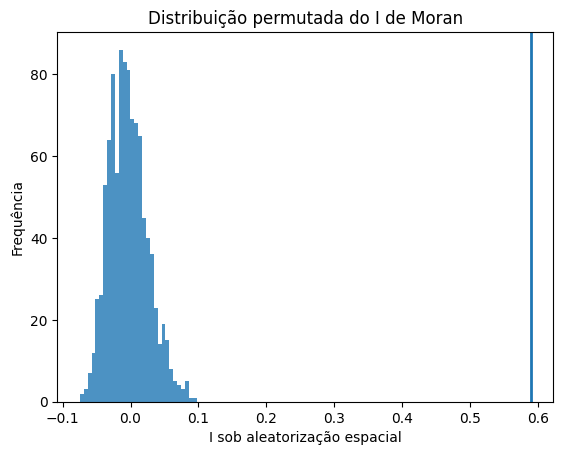

I observado: 0.5892
Valor esperado sob H0: -0.0025
Pseudo p-valor: 0.0010


In [18]:
_, moran_cops = resumo_moran(
    grid_cops["n_cops"],
    w5,
    nome="n_cops",
    permutacoes=999,
)

fig, ax = plt.subplots()
ax.hist(moran_cops.sim, bins=30, alpha=0.8)
ax.axvline(moran_cops.I, linewidth=2)
ax.set_title("Distribuição permutada do I de Moran")
ax.set_xlabel("I sob aleatorização espacial")
ax.set_ylabel("Frequência")
plt.show()

print(f"I observado: {moran_cops.I:.4f}")
print(f"Valor esperado sob H0: {moran_cops.EI:.4f}")
print(f"Pseudo p-valor: {moran_cops.p_sim:.4f}")

## 6. Diagrama de Moran

No diagrama de Moran:

- eixo X = valor padronizado da célula;
- eixo Y = média espacial dos vizinhos;
- inclinação da reta = I de Moran.

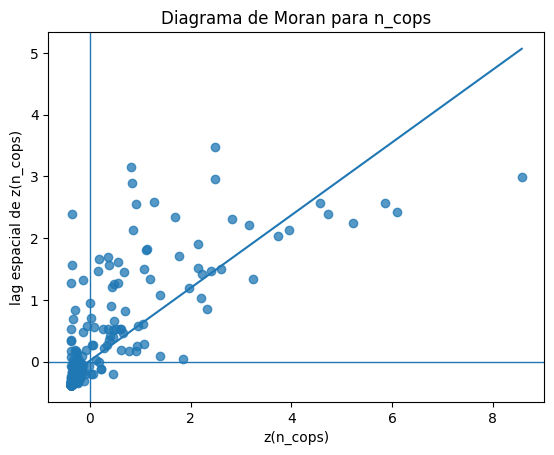

Inclinação estimada: 0.5892
I de Moran: 0.5892


In [19]:
z = (
    grid_cops["n_cops"] - grid_cops["n_cops"].mean()
) / grid_cops["n_cops"].std(ddof=0)

lag_z = lag_spatial(w5, z.to_numpy())

fig, ax = plt.subplots()
ax.scatter(z, lag_z, alpha=0.75)

coef = np.polyfit(z, lag_z, 1)
xline = np.linspace(z.min(), z.max(), 100)
ax.plot(xline, coef[0] * xline + coef[1])

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_xlabel("z(n_cops)")
ax.set_ylabel("lag espacial de z(n_cops)")
ax.set_title("Diagrama de Moran para n_cops")
plt.show()

print(f"Inclinação estimada: {coef[0]:.4f}")
print(f"I de Moran: {moran_cops.I:.4f}")

## 7. LISA — clusters locais e outliers

In [20]:
lisa_cops = Moran_Local(
    grid_cops["n_cops"].to_numpy(),
    w5,
    permutations=999,
)

grid_cops["lisa_q"] = lisa_cops.q
grid_cops["lisa_p"] = lisa_cops.p_sim
grid_cops["cluster_cops"] = [
    classificar_lisa(q, p, alpha=0.05)
    for q, p in zip(grid_cops["lisa_q"], grid_cops["lisa_p"])
]

display(grid_cops["cluster_cops"].value_counts().rename_axis("classe").to_frame("n"))

,n
classe,
NS,218
LL,136
HH,43
LH,4


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning:

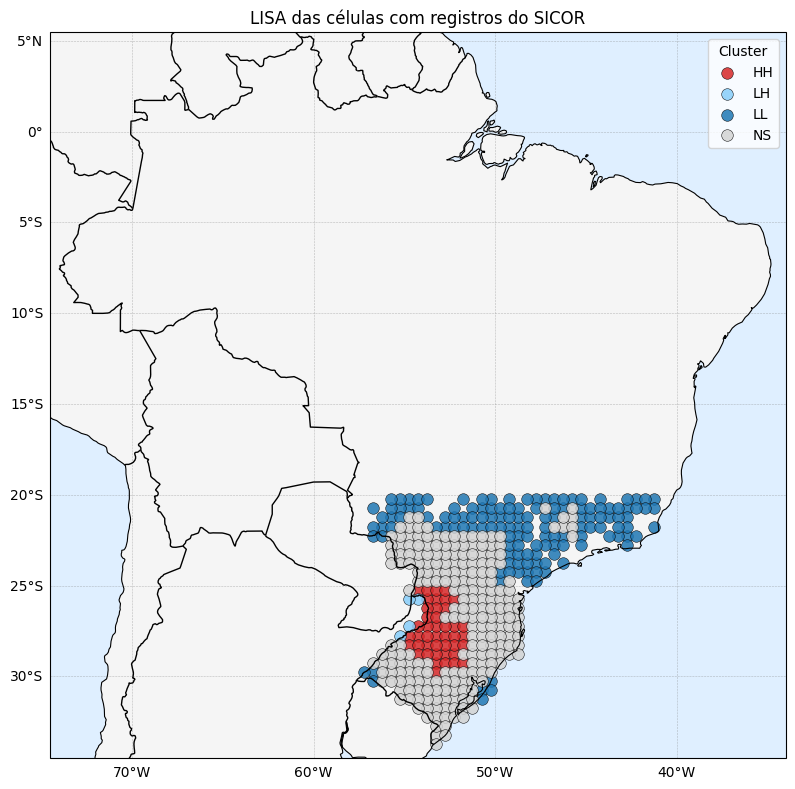

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# seu plot
mapa_cluster(
    ax,
    grid_cops,
    "cluster_cops",
    "LISA das células com registros do SICOR",
)

# recorte do Brasil
ax.set_extent([-74.5, -34.0, -34.5, 5.5], crs=ccrs.PlateCarree())

# fundo
ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="#dfefff", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black", zorder=3)

# bordas internacionais
ax.add_feature(cfeature.BORDERS, linewidth=1.0, edgecolor="black", zorder=3)

# limites dos estados do Brasil
shp_estados = shapereader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces_lines",
)
reader = shapereader.Reader(shp_estados)

geoms_brasil = [
    rec.geometry
    for rec in reader.records()
    if rec.attributes.get("adm0_name") == "Brazil"
]

ax.add_geometries(
    geoms_brasil,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="gray",
    linewidth=0.6,
    zorder=2,
)

# grade
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

plt.tight_layout()
plt.show()

## 8. Ligando SICOR com clima da estação mais próxima

Agora entra o elo com as estações meteorológicas.

Fluxo do exemplo:

1. cada registro do SICOR recebe a **estação mais próxima**;
2. montamos uma **janela de evento** com início/fim;
3. calculamos, nessa janela:
   - precipitação acumulada;
   - temperatura média;
   - temperatura mínima.

> Para o curso, isso já resolve o exemplo. Em produção, vale refinar a janela por fase fenológica e por tipo de evento.

In [22]:
meta_ok = (
    meta_est
    .dropna(subset=["longitude", "latitude"])
    .drop_duplicates(subset=["COD"])
    .copy()
)

tree_est = cKDTree(meta_ok[["longitude", "latitude"]].to_numpy())

dist, idx = tree_est.query(
    df_sicor[["longitude", "latitude"]].to_numpy(),
    k=1,
)

df_sicor["COD_ESTACAO"] = meta_ok.iloc[idx]["COD"].to_numpy()
df_sicor["ESTACAO_PROX"] = meta_ok.iloc[idx]["ESTACAO"].to_numpy()
df_sicor["dist_estacao_graus"] = dist
df_sicor["dist_estacao_km_aprox"] = dist * 111.0

janela = df_sicor.apply(escolher_janela_evento, axis=1)
df_sicor[["janela_ini", "janela_fim"]] = janela

diarios_por_estacao = {
    cod: g.set_index("DATA").sort_index()[["PREC", "TEMP", "TMIN", "TMAX"]]
    for cod, g in df_est_daily.groupby("COD")
}

amostra_max = 3000
if len(df_sicor) > amostra_max:
    df_evento = df_sicor.sample(amostra_max, random_state=42).copy()
else:
    df_evento = df_sicor.copy()

metricas_clima = df_evento.apply(
    clima_no_evento,
    axis=1,
    diarios_por_estacao=diarios_por_estacao,
)

df_evento = pd.concat(
    [df_evento.reset_index(drop=True), metricas_clima.reset_index(drop=True)],
    axis=1,
)

display(
    df_evento[
        [
            "nome_evento", "ESTACAO_PROX", "dist_estacao_km_aprox",
            "janela_ini", "janela_fim",
            "prec_evento_mm", "temp_media_evento_c", "tmin_evento_c",
        ]
    ].head()
)

,nome_evento,ESTACAO_PROX,dist_estacao_km_aprox,janela_ini,janela_fim,prec_evento_mm,temp_media_evento_c,tmin_evento_c
0,Seca,;LAGOA VERMELHA,15.586857,2021-11-15,2022-01-25,177.4,21.834225,9.8
1,Seca,;SANTA ROSA,45.173819,2023-01-17,2023-04-09,159.6,24.741571,7.5
2,Variação excessiva de temperatura,;DOIS VIZINHOS,32.803892,2023-07-10,2023-09-18,455.0,18.469425,5.2
3,Chuva excessiva,;SANTA ROSA,31.166247,2018-10-03,2018-10-10,60.6,19.373438,10.8
4,Seca,;SANTO AUGUSTO,9.040001,2022-01-05,2023-03-22,1949.2,20.167942,0.7


cluster_deficit,HH,HL,LH,LL,NS
cluster_cops,,,,,
HH,0,1,1,7,34
LH,0,0,0,0,3
LL,0,0,0,0,4
NS,1,0,8,6,88


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


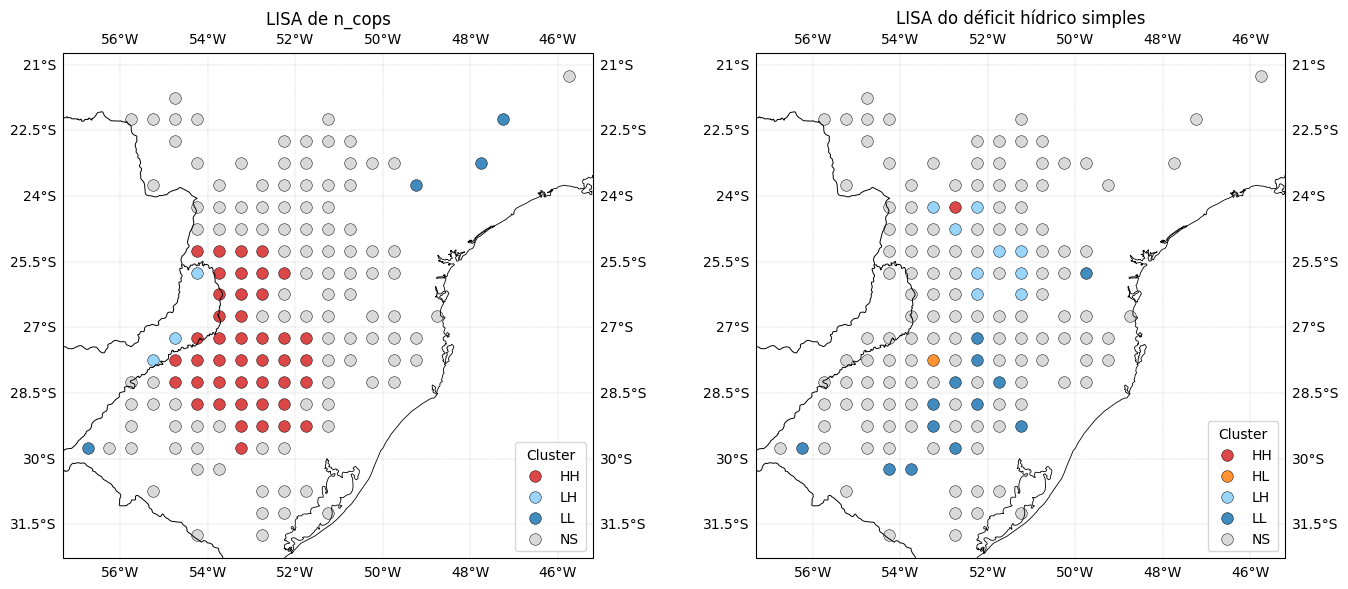

In [24]:
evento_grade = agregar_em_grade(df_evento, step=step)

clima_grade = (
    evento_grade
    .groupby(["grid_id", "grid_lon", "grid_lat"])
    .agg(
        prec_evento_med=("prec_evento_mm", "mean"),
        temp_evento_med=("temp_media_evento_c", "mean"),
        tmin_evento_med=("tmin_evento_c", "mean"),
        dist_est_med_km=("dist_estacao_km_aprox", "mean"),
    )
    .reset_index()
)

grid_join = grid_cops.merge(
    clima_grade,
    on=["grid_id", "grid_lon", "grid_lat"],
    how="left",
)

grid_join["deficit_hidrico_simples"] = -grid_join["prec_evento_med"]

validos_clima = grid_join.dropna(
    subset=["n_cops", "deficit_hidrico_simples"]
).copy()

w_clima = construir_knn(validos_clima, k=5)

lisa_deficit = Moran_Local(
    validos_clima["deficit_hidrico_simples"].to_numpy(),
    w_clima,
    permutations=999,
)

validos_clima["cluster_deficit"] = [
    classificar_lisa(q, p, alpha=0.05)
    for q, p in zip(lisa_deficit.q, lisa_deficit.p_sim)
]

overlay = pd.crosstab(
    validos_clima["cluster_cops"],
    validos_clima["cluster_deficit"],
    dropna=False,
)

display(overlay)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharex=True,
    sharey=True,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mapa_cluster(axes[0], validos_clima, "cluster_cops", "LISA de n_cops")
mapa_cluster(axes[1], validos_clima, "cluster_deficit", "LISA do déficit hídrico simples")

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

### Leitura rápida da sobreposição

Alguns pares úteis para discutir em aula:

- **HH nas COPs + HH no déficit** → coerência espacial;
- **HH nas COPs + NS/LL no clima** → ponto para checagem;
- **NS/LL nas COPs + HH no clima** → possível subnotificação ou diferença de janela.

Esse cruzamento não fecha diagnóstico. Ele só mostra **onde vale olhar mais de perto**.

## 9. Recorrência temporal

,n
classe_recorrencia,
cronico,312
recorrente,57
eventual,32


I de Moran da recorrência: 0.6119
p-valor: 0.0010


/tmp/ipykernel_12607/1664551693.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for classe, sub in recorrencia.groupby("classe_recorrencia"):


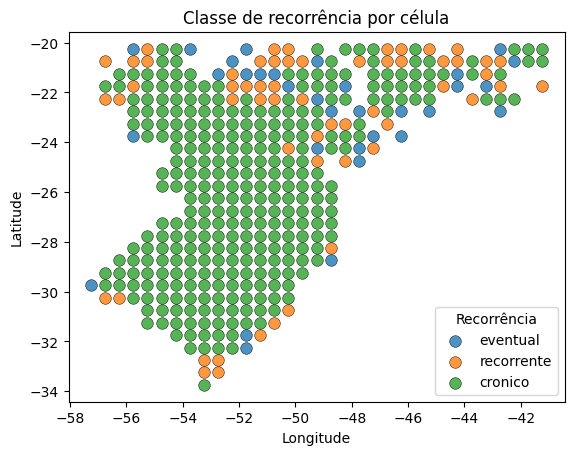

In [25]:
recorrencia = (
    sicor_grade
    .groupby(["grid_id", "grid_lon", "grid_lat"])
    .agg(
        anos_com_cop=("ano_emissao", "nunique"),
        total_cops=("ref_bacen", "size"),
    )
    .reset_index()
)

bins = [-np.inf, 1, 3, np.inf]
labels = ["eventual", "recorrente", "cronico"]
recorrencia["classe_recorrencia"] = pd.cut(
    recorrencia["anos_com_cop"],
    bins=bins,
    labels=labels,
)

display(recorrencia["classe_recorrencia"].value_counts().to_frame("n"))

w_rec = construir_knn(recorrencia, k=5)
_, moran_rec = resumo_moran(
    recorrencia["anos_com_cop"],
    w_rec,
    nome="anos_com_cop",
    permutacoes=999,
)

print(f"I de Moran da recorrência: {moran_rec.I:.4f}")
print(f"p-valor: {moran_rec.p_sim:.4f}")

fig, ax = plt.subplots()
for classe, sub in recorrencia.groupby("classe_recorrencia"):
    ax.scatter(
        sub["grid_lon"],
        sub["grid_lat"],
        s=70,
        label=str(classe),
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4,
    )
ax.set_title("Classe de recorrência por célula")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Recorrência")
plt.show()

## 10. Exemplo por agente institucional

In [ ]:
col_agente = "cd_cpf_perito"
base_agente = df_sicor.dropna(subset=[col_agente]).copy()

if base_agente.empty:
    print("Não há valores válidos para o agente escolhido.")
else:
    top_agente = base_agente[col_agente].value_counts().index[0]
    df_agente = base_agente[base_agente[col_agente] == top_agente].copy()
    agente_grade = agregar_em_grade(df_agente, step=step)

    grid_agente = (
        agente_grade
        .groupby(["grid_id", "grid_lon", "grid_lat"])
        .agg(n_cops_agente=("ref_bacen", "size"))
        .reset_index()
    )

    if len(grid_agente) >= 3:
        w_ag = construir_knn(grid_agente, k=5)
        _, moran_ag = resumo_moran(
            grid_agente["n_cops_agente"],
            w_ag,
            nome="n_cops_agente",
            permutacoes=999,
        )

        print(f"Agente usado: {top_agente}")
        print(f"Unidades espaciais: {len(grid_agente)}")
        print(f"I de Moran: {moran_ag.I:.4f}")
        print(f"p-valor: {moran_ag.p_sim:.4f}")

        fig, ax = plt.subplots()
        tam = 40 + 40 * grid_agente["n_cops_agente"] / grid_agente["n_cops_agente"].max()
        ax.scatter(
            grid_agente["grid_lon"],
            grid_agente["grid_lat"],
            s=tam,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.4,
        )
        ax.set_title(f"Distribuição espacial do agente {top_agente}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.show()
    else:
        print("O agente com mais registros ainda tem poucas unidades espaciais para Moran.")

## 11. MAUP — comparação simples de escala

Aqui a ideia é mostrar que o resultado muda quando a unidade espacial muda.

Vamos calcular o Moran para duas grades:

- **0,5°**
- **1,0°**

In [ ]:
comparacao_maup = []

for step_tmp in [0.5, 1.0]:
    grade_tmp = agregar_em_grade(df_sicor, step=step_tmp)
    grid_tmp = (
        grade_tmp
        .groupby(["grid_id", "grid_lon", "grid_lat"])
        .agg(n_cops=("ref_bacen", "size"))
        .reset_index()
    )

    if len(grid_tmp) < 3:
        continue

    w_tmp = construir_knn(grid_tmp, k=5)
    resumo_tmp, _ = resumo_moran(
        grid_tmp["n_cops"],
        w_tmp,
        nome=f"grade_{step_tmp}",
        permutacoes=999,
    )
    resumo_tmp["step_graus"] = step_tmp
    resumo_tmp["n_unidades"] = len(grid_tmp)
    comparacao_maup.append(resumo_tmp)

df_maup = pd.DataFrame(comparacao_maup)[
    ["step_graus", "n_unidades", "I", "p_sim", "z_sim"]
]
df_maup

## 12. Fechamento

Com este notebook, você já tem um exemplo curto de cada tema principal da aula:

- valor espacial e média dos vizinhos → **Lei de Tobler**
- medida única do padrão → **I de Moran**
- mudança do critério de vizinhança → **sensibilidade da matriz**
- histograma permutado → **significância**
- gráfico valor × lag espacial → **diagrama de Moran**
- mapa HH / LL / HL / LH → **LISA**
- cruzamento com precipitação da estação → **coerência SICOR × clima**
- contagem ao longo dos anos → **recorrência**
- recorte por perito → **agente institucional**
- duas grades diferentes → **MAUP**

## Próximos passos naturais

1. trocar a grade por município;
2. separar por tipo de evento (`seca`, `geada`, `chuva excessiva`);
3. montar janelas climáticas por fase fenológica;
4. aplicar correção para múltiplos testes;
5. gerar mapas finais com base cartográfica.

Se quiser deixar este notebook pronto para aula, o próximo passo mais útil é encaixar gráficos com legenda final e uma seção curta de interpretação em cada bloco.